In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import OneCycleLR

import copy
import warnings
import time
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('='*80)
print('ENVIRONMENT SETUP')
print('='*80)
print(f'PyTorch Version: {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU Device: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')
print('='*80)


ENVIRONMENT SETUP
PyTorch Version: 2.6.0+cu124
Device: cuda
GPU Device: Tesla T4
GPU Memory: 14.74 GB


In [2]:
df = pd.read_csv("/kaggle/input/data-fed-learn/train.csv")
print('='*80)
print('DATASET OVERVIEW')
print('='*80)
print(f'Dataset Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print('Risk Rate:', df['Risk_Flag'].mean() * 100, '%')

# Drop ID and feature engineering
df_processed = df.drop(columns=['Id']).copy()
df_processed['Income_Age_Ratio'] = df_processed['Income'] / (df_processed['Age'] + 1)
df_processed['Exp_Job_Ratio'] = df_processed['Experience'] / (df_processed['CURRENT_JOB_YRS'] + 1)
df_processed['Stability_Score'] = df_processed['CURRENT_JOB_YRS'] + df_processed['CURRENT_HOUSE_YRS']
df_processed['Married_Income_Interaction'] = df_processed['Income'] * pd.to_numeric(
    df_processed['Married.Single'], errors='coerce').fillna(0)

# Encode categoricals
categorical_cols = []
for col in df_processed.columns:
    if col == 'Risk_Flag': continue
    if df_processed[col].dtype == 'object' or df_processed[col].nunique() < 50:
        categorical_cols.append(col)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le

print('✅ Preprocessing complete | Shape:', df_processed.shape)


DATASET OVERVIEW
Dataset Shape: (176400, 13)
Columns: ['Id', 'Income', 'Age', 'Experience', 'Married.Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag']
Risk Rate: 12.276643990929704 %
✅ Preprocessing complete | Shape: (176400, 16)


In [3]:
X = df_processed.drop(columns=['Risk_Flag'])
y = df_processed['Risk_Flag']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]

X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).to(device)
X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
y_val_tensor = torch.FloatTensor(y_val.values).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).to(device)

print(f'✅ Split: Train={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}')
print(f'✅ Feature dim: {input_dim}')


✅ Split: Train=141137 | Val=17623 | Test=17640
✅ Feature dim: 15


In [4]:
class UpgradedLoanDefaultNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64, 32], dropout_rate=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        layers.extend([nn.Linear(prev_dim, 1), nn.Sigmoid()])
        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        return self.network(x)

class EnhancedFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=3.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

print('✅ Models defined')


✅ Models defined


In [5]:
def compute_f1_batch(outputs, targets, threshold=0.5):
    preds = (outputs > threshold).float()
    return f1_score(targets.cpu().numpy(), preds.cpu().numpy(), zero_division=0)

def train_central(model, X_train, y_train, X_val, y_val, epochs=300, batch_size=512, lr=0.005):
    criterion = EnhancedFocalLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=512, shuffle=False)
    
    scheduler = OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=epochs, pct_start=0.2)
    history = {'train_f1': [], 'val_f1': [], 'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_f1_total, train_count = 0, 0, 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y.view(-1, 1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item() * batch_y.size(0)
            train_f1_total += compute_f1_batch(outputs, batch_y) * batch_y.size(0)
            train_count += batch_y.size(0)
        
        model.eval()
        val_loss, val_f1_total, val_count = 0, 0, 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y.view(-1, 1))
                val_loss += loss.item() * batch_y.size(0)
                val_f1_total += compute_f1_batch(outputs, batch_y) * batch_y.size(0)
                val_count += batch_y.size(0)
        
        history['train_f1'].append(train_f1_total / train_count)
        history['val_f1'].append(val_f1_total / val_count)
        history['train_loss'].append(train_loss / len(X_train))
        history['val_loss'].append(val_loss / len(X_val))
        
        if epoch % 50 == 0:
            print(f'Epoch {epoch+1:3d} | Train F1: {history["train_f1"][-1]:.4f} | Val F1: {history["val_f1"][-1]:.4f}')
    
    return history

central_model = UpgradedLoanDefaultNN(input_dim).to(device)
central_history = train_central(central_model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor)
print(f'✅ Central Training Complete | Final Val F1: {central_history["val_f1"][-1]:.4f}')


Epoch   1 | Train F1: 0.1385 | Val F1: 0.0000
Epoch  51 | Train F1: 0.0539 | Val F1: 0.0000
Epoch 101 | Train F1: 0.2523 | Val F1: 0.3036
Epoch 151 | Train F1: 0.3170 | Val F1: 0.4008
Epoch 201 | Train F1: 0.3565 | Val F1: 0.4698
Epoch 251 | Train F1: 0.3992 | Val F1: 0.4572
✅ Central Training Complete | Final Val F1: 0.4593


In [6]:
def create_client_clusters(X_train, y_train, num_clients=5, num_chunks=20):
    print('='*80)
    print(f'GMM CLUSTERING: 5 CLIENTS × 20 CHUNKS/CLIENT (NO OVERLAP)')
    print('='*80)
    
    pca = PCA(n_components=min(50, X_train.shape[1]))
    X_pca = pca.fit_transform(X_train.cpu().numpy())
    
    gmm = GaussianMixture(n_components=num_clients, random_state=42, max_iter=200)
    cluster_labels = gmm.fit_predict(X_pca)
    
    client_data = []
    for i in range(num_clients):
        mask = cluster_labels == i
        client_X = X_train[mask]
        client_y = y_train[mask]
        
        # Split into 20 chunks (no overlap)
        n_samples = len(client_X)
        chunk_size = n_samples // num_chunks
        chunks = []
        
        for j in range(num_chunks):
            start = j * chunk_size
            end = min((j + 1) * chunk_size, n_samples)
            chunks.append((client_X[start:end], client_y[start:end]))
        
        risk_rate = client_y.mean().item() * 100
        print(f'Client {i+1}: {n_samples:,} samples | Risk: {risk_rate:5.2f}% | {num_chunks} chunks')
        client_data.append(chunks)
    
    print('='*80)
    return client_data, cluster_labels

fixed_client_data, cluster_labels = create_client_clusters(X_train_tensor, y_train_tensor)


GMM CLUSTERING: 5 CLIENTS × 20 CHUNKS/CLIENT (NO OVERLAP)
Client 1: 31,210 samples | Risk: 12.54% | 20 chunks
Client 2: 16,218 samples | Risk: 12.58% | 20 chunks
Client 3: 12,729 samples | Risk: 14.60% | 20 chunks
Client 4: 35,403 samples | Risk: 10.50% | 20 chunks
Client 5: 45,577 samples | Risk: 12.71% | 20 chunks


In [7]:
def train_fedavg(client_data, num_rounds=20, local_epochs=15, batch_size=256, lr=0.005):
    global_model = UpgradedLoanDefaultNN(input_dim).to(device)
    global_model.load_state_dict(central_model.state_dict())
    criterion = EnhancedFocalLoss()
    history = {'round': [], 'avg_f1': [], 'client_f1': []}
    
    print('='*80)
    print(f'FEDAVG: {num_rounds} Rounds × {local_epochs} Local Epochs/Client')
    print('='*80)
    
    for round_num in range(num_rounds):
        client_f1s = []
        local_weights = []
        
        for client_id in range(len(client_data)):
            client_X, client_y = client_data[client_id][round_num]
            
            local_model = UpgradedLoanDefaultNN(input_dim).to(device)
            local_model.load_state_dict(global_model.state_dict())
            optimizer = optim.AdamW(local_model.parameters(), lr=lr, weight_decay=1e-4)
            client_loader = DataLoader(TensorDataset(client_X, client_y), batch_size=batch_size, shuffle=True)
            
            # 15 local epochs
            for _ in range(local_epochs):
                local_model.train()
                for batch_X, batch_y in client_loader:
                    optimizer.zero_grad()
                    outputs = local_model(batch_X)
                    loss = criterion(outputs, batch_y.view(-1, 1))
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), 1.0)
                    optimizer.step()
            
            # Client F1
            local_model.eval()
            with torch.no_grad():
                outputs = local_model(client_X)
                client_f1 = f1_score(client_y.cpu(), (outputs > 0.5).cpu().float().numpy(), zero_division=0)
                client_f1s.append(client_f1)
            
            local_weights.append(copy.deepcopy(local_model.state_dict()))
        
        # FedAvg aggregation
        global_weights = copy.deepcopy(local_weights[0])
        for key in global_weights.keys():
            for i in range(1, len(local_weights)):
                global_weights[key] += local_weights[i][key]
            global_weights[key] /= len(local_weights)
        global_model.load_state_dict(global_weights)
        
        avg_f1 = np.mean(client_f1s)
        history['round'].append(round_num)
        history['avg_f1'].append(avg_f1)
        history['client_f1'].append(client_f1s)
        
        print(f'R{round_num+1:2d} | Avg F1: {avg_f1:.4f} | Clients: [{", ".join(f"{f1:.3f}" for f1 in client_f1s)}]')
    
    return global_model, history

fedavg_model, fedavg_history = train_fedavg(fixed_client_data)


FEDAVG: 20 Rounds × 15 Local Epochs/Client
R 1 | Avg F1: 0.7544 | Clients: [0.720, 0.843, 0.812, 0.688, 0.709]
R 2 | Avg F1: 0.7579 | Clients: [0.735, 0.856, 0.788, 0.715, 0.696]
R 3 | Avg F1: 0.7547 | Clients: [0.702, 0.798, 0.823, 0.756, 0.694]
R 4 | Avg F1: 0.7475 | Clients: [0.710, 0.830, 0.822, 0.740, 0.636]
R 5 | Avg F1: 0.7256 | Clients: [0.725, 0.760, 0.749, 0.696, 0.698]
R 6 | Avg F1: 0.7538 | Clients: [0.744, 0.808, 0.781, 0.690, 0.747]
R 7 | Avg F1: 0.7371 | Clients: [0.611, 0.854, 0.766, 0.738, 0.717]
R 8 | Avg F1: 0.7303 | Clients: [0.592, 0.820, 0.771, 0.727, 0.742]
R 9 | Avg F1: 0.7178 | Clients: [0.698, 0.829, 0.706, 0.697, 0.659]
R10 | Avg F1: 0.7223 | Clients: [0.696, 0.802, 0.782, 0.685, 0.647]
R11 | Avg F1: 0.7176 | Clients: [0.678, 0.872, 0.742, 0.643, 0.653]
R12 | Avg F1: 0.7141 | Clients: [0.743, 0.822, 0.768, 0.695, 0.543]
R13 | Avg F1: 0.6764 | Clients: [0.674, 0.747, 0.677, 0.685, 0.600]
R14 | Avg F1: 0.7344 | Clients: [0.705, 0.847, 0.816, 0.657, 0.648]
R15 |

In [8]:
class UCBClientSelector:
    def __init__(self, num_clients, c=1.5):
        self.num_clients = num_clients
        self.c = c
        self.rewards = np.zeros(num_clients)
        self.counts = np.zeros(num_clients)
        self.total_counts = 0

    def select_clients(self, num_select):
        if self.total_counts < self.num_clients:
            return list(range(self.num_clients))
        
        ucb_values = np.zeros(self.num_clients)
        for i in range(self.num_clients):
            if self.counts[i] == 0:
                ucb_values[i] = float('inf')
            else:
                avg_reward = self.rewards[i] / self.counts[i]
                exploration = self.c * np.sqrt(np.log(self.total_counts + 1) / (self.counts[i] + 1))
                ucb_values[i] = avg_reward + exploration
        return np.argsort(ucb_values)[-num_select:].tolist()

    def update(self, client_id, reward):
        self.counts[client_id] += 1
        self.rewards[client_id] += reward
        self.total_counts += 1

def train_flmab(client_data, num_rounds=20, clients_per_round=3, local_epochs=15, batch_size=256, lr=0.005):
    global_model = UpgradedLoanDefaultNN(input_dim).to(device)
    global_model.load_state_dict(central_model.state_dict())
    mab_selector = UCBClientSelector(len(client_data))
    criterion = EnhancedFocalLoss()
    history = {'round': [], 'avg_f1': [], 'selected_clients': []}
    
    print('='*80)
    print(f'FL-MAB: {num_rounds} Rounds × {local_epochs} Epochs × Top-{clients_per_round}')
    print('='*80)
    
    for round_num in range(num_rounds):
        selected_clients = mab_selector.select_clients(clients_per_round)
        client_f1s = []
        local_weights = []
        
        for client_id in selected_clients:
            client_X, client_y = client_data[client_id][round_num]
            
            local_model = UpgradedLoanDefaultNN(input_dim).to(device)
            local_model.load_state_dict(global_model.state_dict())
            optimizer = optim.AdamW(local_model.parameters(), lr=lr, weight_decay=1e-4)
            client_loader = DataLoader(TensorDataset(client_X, client_y), batch_size=batch_size, shuffle=True)
            
            for _ in range(local_epochs):
                local_model.train()
                for batch_X, batch_y in client_loader:
                    optimizer.zero_grad()
                    outputs = local_model(batch_X)
                    loss = criterion(outputs, batch_y.view(-1, 1))
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), 1.0)
                    optimizer.step()
            
            local_model.eval()
            with torch.no_grad():
                outputs = local_model(client_X)
                client_f1 = f1_score(client_y.cpu(), (outputs > 0.5).cpu().float().numpy(), zero_division=0)
                mab_selector.update(client_id, client_f1)
                client_f1s.append(client_f1)
                local_weights.append(copy.deepcopy(local_model.state_dict()))
        
        # FedAvg on selected clients
        global_weights = copy.deepcopy(local_weights[0])
        for key in global_weights.keys():
            for i in range(1, len(local_weights)):
                global_weights[key] += local_weights[i][key]
            global_weights[key] /= len(local_weights)
        global_model.load_state_dict(global_weights)
        
        avg_f1 = np.mean(client_f1s)
        history['round'].append(round_num)
        history['avg_f1'].append(avg_f1)
        history['selected_clients'].append(selected_clients)
        
        print(f'R{round_num+1:2d} | Clients: {[c+1 for c in selected_clients]} | F1: {avg_f1:.4f}')
    
    return global_model, history, mab_selector

flmab_model, flmab_history, mab_selector = train_flmab(fixed_client_data)


FL-MAB: 20 Rounds × 15 Epochs × Top-3
R 1 | Clients: [1, 2, 3, 4, 5] | F1: 0.7514
R 2 | Clients: [4, 2, 3] | F1: 0.7864
R 3 | Clients: [2, 1, 5] | F1: 0.7406
R 4 | Clients: [1, 4, 3] | F1: 0.7179
R 5 | Clients: [3, 2, 5] | F1: 0.7410
R 6 | Clients: [5, 4, 1] | F1: 0.7220
R 7 | Clients: [1, 3, 2] | F1: 0.7389
R 8 | Clients: [5, 4, 2] | F1: 0.7463
R 9 | Clients: [1, 2, 3] | F1: 0.7297
R10 | Clients: [3, 5, 4] | F1: 0.6876
R11 | Clients: [1, 3, 2] | F1: 0.7583
R12 | Clients: [4, 2, 5] | F1: 0.7148
R13 | Clients: [2, 3, 1] | F1: 0.7106
R14 | Clients: [3, 5, 4] | F1: 0.6517
R15 | Clients: [4, 1, 2] | F1: 0.7476
R16 | Clients: [1, 5, 3] | F1: 0.6948
R17 | Clients: [3, 4, 2] | F1: 0.6516
R18 | Clients: [5, 1, 2] | F1: 0.6795
R19 | Clients: [1, 3, 2] | F1: 0.7282
R20 | Clients: [5, 2, 4] | F1: 0.6952


In [9]:
def evaluate_model(model, X, y, model_name='Model', threshold=0.5, verbose=True):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        y_prob = outputs.cpu().numpy().flatten()
        y_true = y.cpu().numpy()
        y_pred = (y_prob > threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_prob)

    metrics = {'model': model_name, 'threshold': threshold, 'accuracy': accuracy,
              'precision': precision, 'recall': recall, 'f1score': f1, 'aucroc': auc_roc}
    
    if verbose:
        print(f'\n{model_name} (thr={threshold:.3f}) | F1: {f1:.4f} | AUC: {auc_roc:.4f}')
    
    return metrics, y_true, y_pred, y_prob

def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 200)
    best_thr, best_f1 = 0.5, 0
    for thr in thresholds:
        f1 = f1_score(y_true, (y_prob > thr).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1


In [10]:
print('='*80)
print('FINAL TEST EVALUATION')
print('='*80)

# Evaluate at default threshold
central_metrics_05, central_ytrue, _, central_yprob = evaluate_model(central_model, X_test_tensor, y_test_tensor, 'Central', 0.5, verbose=True)
fedavg_metrics_05, fedavg_ytrue, _, fedavg_yprob = evaluate_model(fedavg_model, X_test_tensor, y_test_tensor, 'FedAvg', 0.5, verbose=True)
flmab_metrics_05, flmab_ytrue, _, flmab_yprob = evaluate_model(flmab_model, X_test_tensor, y_test_tensor, 'FL-MAB', 0.5, verbose=True)

# Find best thresholds
best_central_thr, _ = find_best_threshold(central_ytrue, central_yprob)
best_fedavg_thr, _ = find_best_threshold(fedavg_ytrue, fedavg_yprob)
best_flmab_thr, _ = find_best_threshold(flmab_ytrue, flmab_yprob)

# Evaluate at best thresholds
central_best, _, _, _ = evaluate_model(central_model, X_test_tensor, y_test_tensor, 'Central-Best', best_central_thr)
fedavg_best, _, _, _ = evaluate_model(fedavg_model, X_test_tensor, y_test_tensor, 'FedAvg-Best', best_fedavg_thr)
flmab_best, _, _, _ = evaluate_model(flmab_model, X_test_tensor, y_test_tensor, 'FLMAB-Best', best_flmab_thr)

comparison_df = pd.DataFrame([central_best, fedavg_best, flmab_best])
print('\n' + '='*80)
print('FINAL RESULTS (BEST THRESHOLDS)')
print(comparison_df.round(4)[['model', 'threshold', 'f1score', 'aucroc']].to_string(index=False))


FINAL TEST EVALUATION

Central (thr=0.500) | F1: 0.4392 | AUC: 0.8940

FedAvg (thr=0.500) | F1: 0.3452 | AUC: 0.8630

FL-MAB (thr=0.500) | F1: 0.3477 | AUC: 0.8512

Central-Best (thr=0.424) | F1: 0.6301 | AUC: 0.8940

FedAvg-Best (thr=0.365) | F1: 0.5786 | AUC: 0.8630

FLMAB-Best (thr=0.369) | F1: 0.5514 | AUC: 0.8512

FINAL RESULTS (BEST THRESHOLDS)
       model  threshold  f1score  aucroc
Central-Best     0.4237   0.6301  0.8940
 FedAvg-Best     0.3646   0.5786  0.8630
  FLMAB-Best     0.3695   0.5514  0.8512


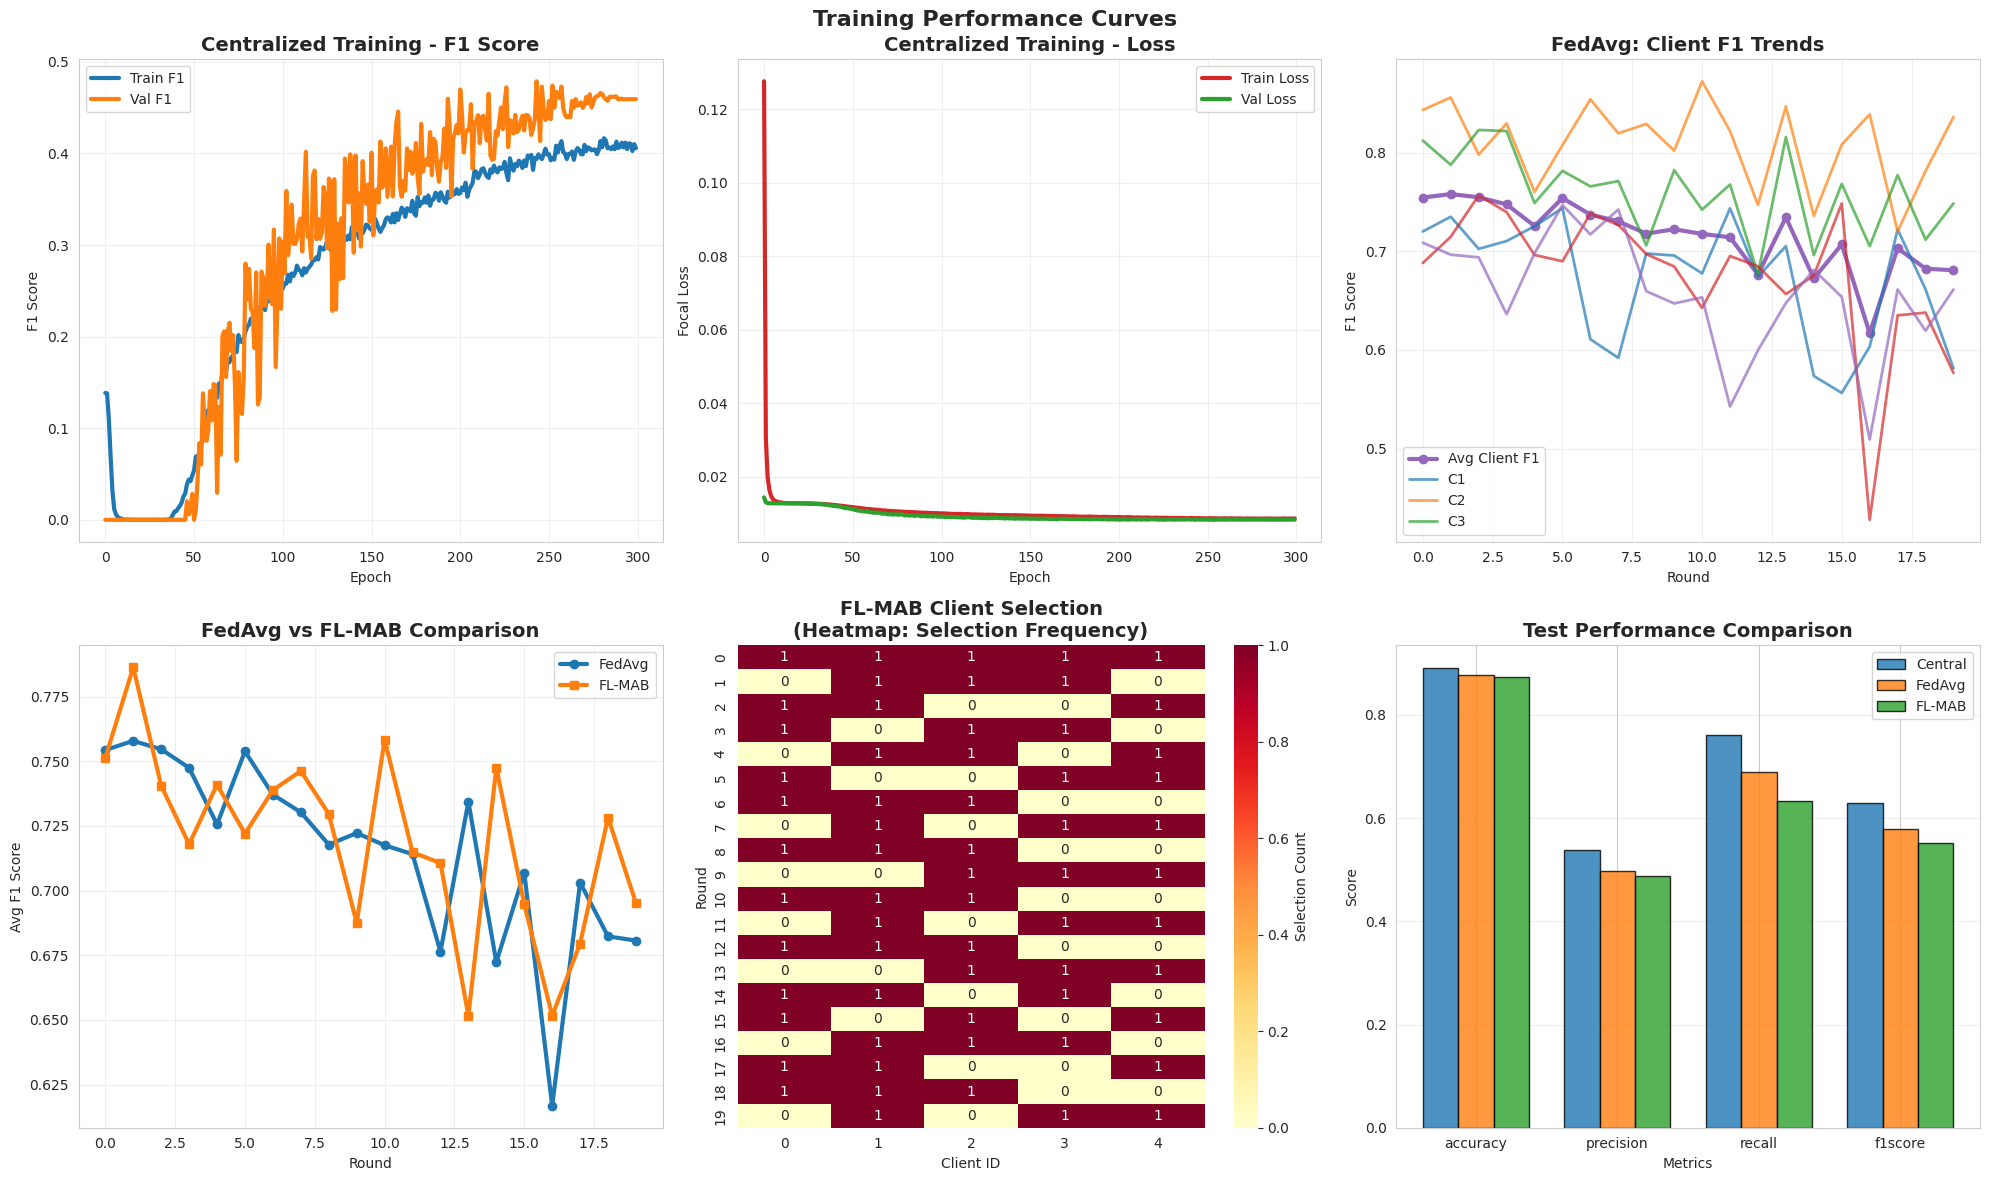

✅ CELL 11 FIXED & PLOTS SAVED!


In [12]:
# =============================================================================
# CELL 11: FIXED RESEARCH PAPER PLOTS - TRAINING CURVES
# =============================================================================
plt.style.use('default')
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Training Performance Curves', fontsize=16, fontweight='bold')  # ✅ FIXED: removed 'pad'

# 1. Central F1
axes[0,0].plot(central_history['train_f1'], label='Train F1', linewidth=3, color='#1f77b4')
axes[0,0].plot(central_history['val_f1'], label='Val F1', linewidth=3, color='#ff7f0e')
axes[0,0].set_title('Centralized Training - F1 Score', fontweight='bold', fontsize=14)
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('F1 Score')
axes[0,0].legend(frameon=True)
axes[0,0].grid(True, alpha=0.3)

# 2. Central Loss
axes[0,1].plot(central_history['train_loss'], label='Train Loss', linewidth=3, color='#d62728')
axes[0,1].plot(central_history['val_loss'], label='Val Loss', linewidth=3, color='#2ca02c')
axes[0,1].set_title('Centralized Training - Loss', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Focal Loss')
axes[0,1].legend(frameon=True)
axes[0,1].grid(True, alpha=0.3)

# 3. FedAvg Client F1 (Avg + Individual clients)
rounds = np.arange(20)
axes[0,2].plot(rounds, fedavg_history['avg_f1'], 'o-', linewidth=3, markersize=6, 
               label='Avg Client F1', color='#9467bd')
for i in range(5):
    client_f1s = [f1s[i] for f1s in fedavg_history['client_f1']]
    axes[0,2].plot(rounds, client_f1s, alpha=0.7, linewidth=2, label=f'C{i+1}' if i<3 else "")
axes[0,2].set_title('FedAvg: Client F1 Trends', fontweight='bold', fontsize=14)
axes[0,2].set_xlabel('Round')
axes[0,2].set_ylabel('F1 Score')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. FL-MAB vs FedAvg Comparison
axes[1,0].plot(rounds, fedavg_history['avg_f1'], 'o-', linewidth=3, markersize=6, 
               label='FedAvg', color='#1f77b4')
axes[1,0].plot(rounds, flmab_history['avg_f1'], 's-', linewidth=3, markersize=6, 
               label='FL-MAB', color='#ff7f0e')
axes[1,0].set_title('FedAvg vs FL-MAB Comparison', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('Round')
axes[1,0].set_ylabel('Avg F1 Score')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5. FL-MAB Client Selection Heatmap
selection_matrix = np.zeros((20, 5))
for r, clients in enumerate(flmab_history['selected_clients']):
    for c in clients:
        selection_matrix[r, c] += 1
sns.heatmap(selection_matrix, annot=True, fmt='.0f', cmap='YlOrRd', 
            ax=axes[1,1], cbar_kws={'label': 'Selection Count'})
axes[1,1].set_title('FL-MAB Client Selection\n(Heatmap: Selection Frequency)', 
                   fontweight='bold', fontsize=14)
axes[1,1].set_xlabel('Client ID')
axes[1,1].set_ylabel('Round')

# 6. Final Metrics Bar Plot
metrics = ['accuracy', 'precision', 'recall', 'f1score']
x = np.arange(len(metrics))
width = 0.25
models = [central_best, fedavg_best, flmab_best]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
model_names = ['Central', 'FedAvg', 'FL-MAB']

for i, model in enumerate(models):
    axes[1,2].bar(x + i*width, [model[m] for m in metrics], width, 
                  label=model_names[i], color=colors[i], alpha=0.8, edgecolor='black')

axes[1,2].set_title('Test Performance Comparison', fontweight='bold', fontsize=14)
axes[1,2].set_xlabel('Metrics')
axes[1,2].set_ylabel('Score')
axes[1,2].set_xticks(x + width)
axes[1,2].set_xticklabels(metrics)
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('training_curves_research.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print('✅ CELL 11 FIXED & PLOTS SAVED!')


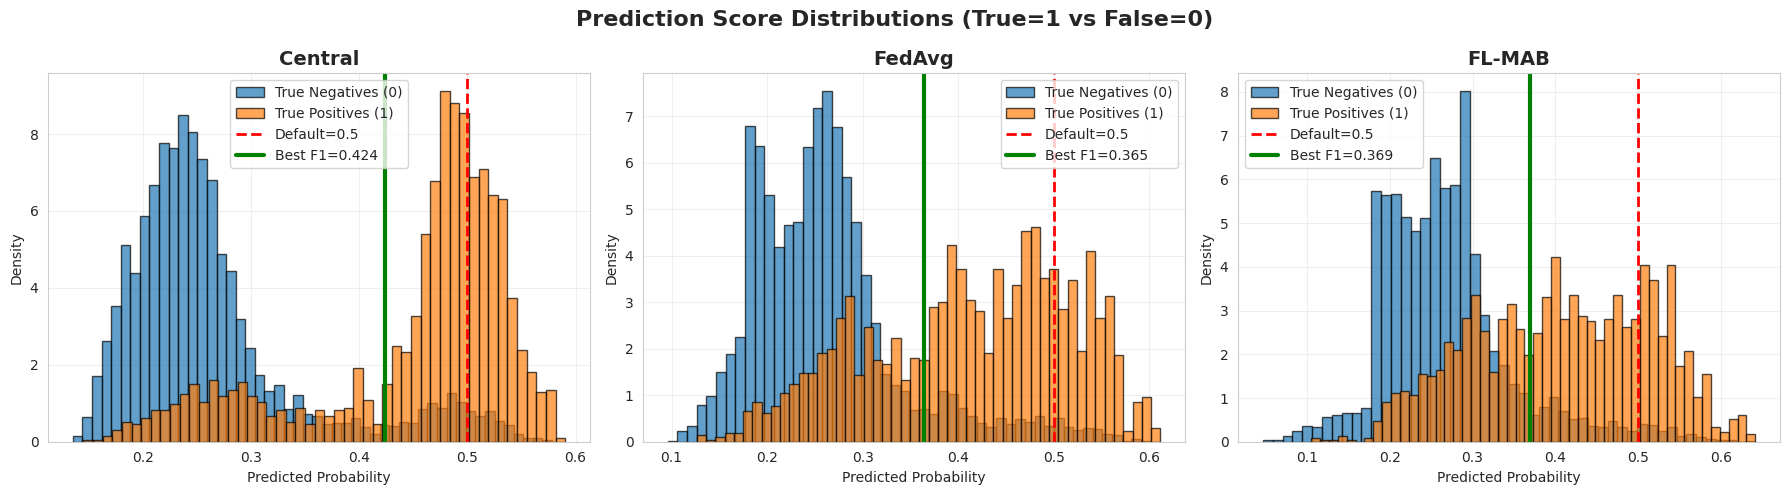

✅ CELL 12 FIXED & THRESHOLD HISTOGRAMS SAVED!


In [13]:
# =============================================================================
# CELL 12: FIXED THRESHOLD HISTOGRAMS
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Prediction Score Distributions (True=1 vs False=0)', fontsize=16, fontweight='bold')

models_data = [
    ('Central', central_ytrue, central_yprob, best_central_thr),
    ('FedAvg', fedavg_ytrue, fedavg_yprob, best_fedavg_thr),
    ('FL-MAB', flmab_ytrue, flmab_yprob, best_flmab_thr)
]

for idx, (name, y_true, y_prob, best_thr) in enumerate(models_data):
    ax = axes[idx]
    
    # True Negatives (0)
    tn_mask = y_true == 0
    ax.hist(y_prob[tn_mask], bins=50, alpha=0.7, color='#1f77b4', 
            label='True Negatives (0)', density=True, edgecolor='black')
    
    # True Positives (1)
    tp_mask = y_true == 1
    ax.hist(y_prob[tp_mask], bins=50, alpha=0.7, color='#ff7f0e', 
            label='True Positives (1)', density=True, edgecolor='black')
    
    ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Default=0.5')
    ax.axvline(best_thr, color='green', linestyle='-', linewidth=3, 
               label=f'Best F1={best_thr:.3f}')
    
    ax.set_title(f'{name}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_histograms_research.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ CELL 12 FIXED & THRESHOLD HISTOGRAMS SAVED!')


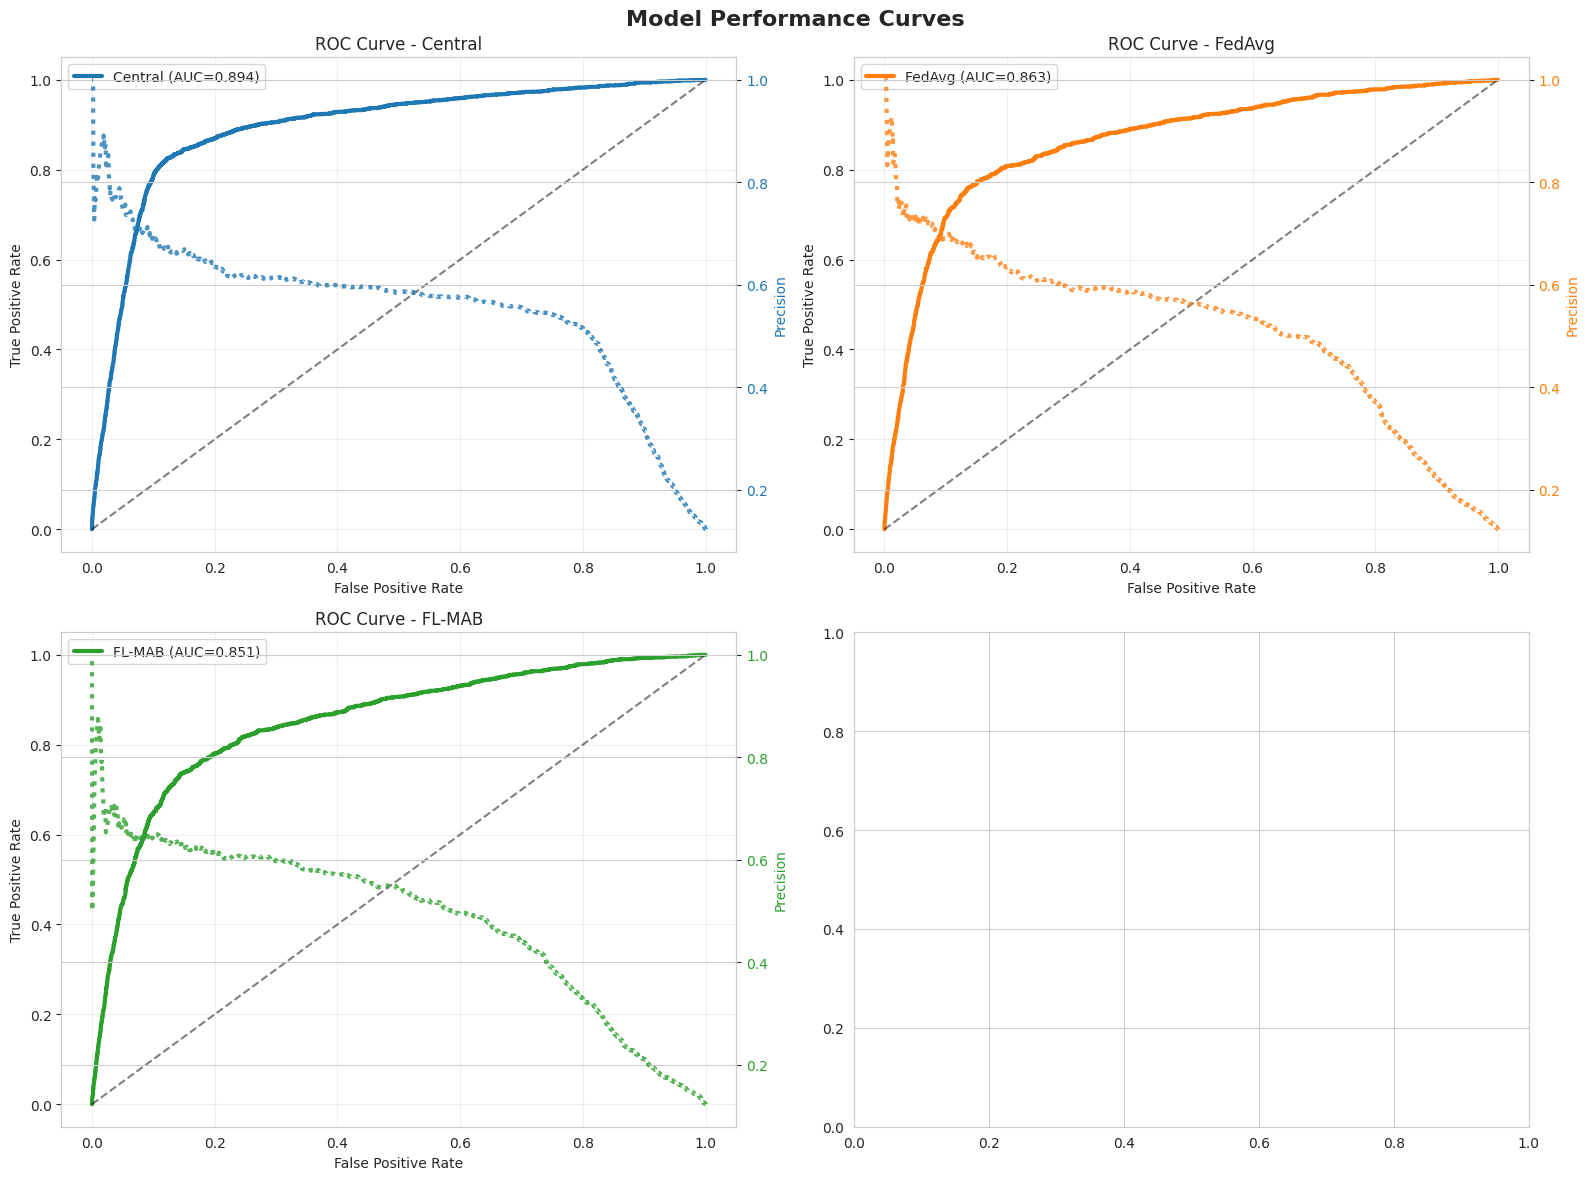

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Curves', fontsize=16, fontweight='bold')

# ROC Curves
for ax, (name, y_true, y_prob), color in zip(axes.flat, 
    [('Central', central_ytrue, central_yprob), 
     ('FedAvg', fedavg_ytrue, fedavg_yprob),
     ('FL-MAB', flmab_ytrue, flmab_yprob)], 
    ['#1f77b4', '#ff7f0e', '#2ca02c']):
    
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=3, label=f'{name} (AUC={roc_auc:.3f})')
    ax.plot([0,1], [0,1], 'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ax_twin = ax.twinx()
    ax_twin.plot(recall, precision, color=color, lw=3, linestyle=':', alpha=0.8)
    ax_twin.set_ylabel('Precision', color=color)
    ax_twin.tick_params(axis='y', labelcolor=color)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
torch.save(central_model.state_dict(), 'central_model_final.pth')
torch.save(fedavg_model.state_dict(), 'fedavg_model_20r_15e.pth')
torch.save(flmab_model.state_dict(), 'flmab_model_20r_15e.pth')

pd.DataFrame(central_history).to_csv('central_history.csv', index=False)
pd.DataFrame(fedavg_history).to_csv('fedavg_history.csv', index=False)
pd.DataFrame(flmab_history).to_csv('flmab_history.csv', index=False)
comparison_df.to_csv('final_comparison.csv', index=False)

print('='*80)
print('✅ COMPLETE EXPERIMENT SAVED:')
print('- Models: central_model_final.pth, fedavg_model_20r_15e.pth, flmab_model_20r_15e.pth')
print('- Plots: training_curves_research.png, threshold_histograms_research.png, roc_pr_curves.png')
print('- Data: all histories + final_comparison.csv')
print('='*80)
